# 05 Portfolio Simulation

Starter simulation for a simple Polymarket betting model.

Assumptions for this first pass:

- Initial portfolio value is `$1,000`.
- There are `1,000` independent trades.
- Each trade stakes a fixed `$10`.
- The market price is fair: a `65c` YES share resolves YES with probability `65%`.
- No fees, slippage, spreads, or market impact are included.
- Each winning YES trade pays `$1` per share, so staking `stake` at price `p` buys `stake / p` shares.

Under fair odds, this is a zero-expected-value game before fees. The goal here is to visualize path variance, not to model edge yet.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

In [16]:
INITIAL_PORTFOLIO = 1_000.0
TRADE_STAKE = 10.0
N_TRADES = 1_000
N_PATHS = 50
FAIR_YES_PRICE = 0.65
RANDOM_SEED = None

## Fixed-Stake Fair-Odds Model

If a YES share costs `p`, staking `$10` buys `10 / p` shares.

- If YES resolves correctly, the trade receives `10 / p` dollars back, for profit `10 * (1 / p - 1)`.
- If YES resolves incorrectly, the trade loses the full `$10` stake.

When `p` is also the true probability of YES, expected profit is zero:

`p * stake * (1 / p - 1) + (1 - p) * (-stake) = 0`

In [17]:
def simulate_fixed_stake_paths(
    *,
    initial_portfolio: float,
    trade_stake: float,
    n_trades: int,
    n_paths: int,
    yes_price: float,
    seed: int | None = None,
) -> pd.DataFrame:
    """Simulate fixed-size YES bets at fair Polymarket odds."""
    if not 0 < yes_price < 1:
        raise ValueError("yes_price must be between 0 and 1.")
    if trade_stake <= 0:
        raise ValueError("trade_stake must be positive.")
    if initial_portfolio <= 0:
        raise ValueError("initial_portfolio must be positive.")

    rng = np.random.default_rng(seed)
    wins = rng.random((n_trades, n_paths)) < yes_price

    win_profit = trade_stake * (1 / yes_price - 1)
    loss_profit = -trade_stake
    trade_pnl = np.where(wins, win_profit, loss_profit)

    portfolio_values = initial_portfolio + np.vstack(
        [np.zeros(n_paths), np.cumsum(trade_pnl, axis=0)]
    )

    return pd.DataFrame(
        portfolio_values,
        index=pd.RangeIndex(0, n_trades + 1, name="trade_number"),
        columns=[f"path_{i + 1}" for i in range(n_paths)],
    )


paths = simulate_fixed_stake_paths(
    initial_portfolio=INITIAL_PORTFOLIO,
    trade_stake=TRADE_STAKE,
    n_trades=N_TRADES,
    n_paths=N_PATHS,
    yes_price=FAIR_YES_PRICE,
    seed=RANDOM_SEED,
)

paths.head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_41,path_42,path_43,path_44,path_45,path_46,path_47,path_48,path_49,path_50
trade_number,,,,,,,,,,,,,,,,,,,,,
0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
1,990.000000,990.000000,1005.384615,1005.384615,990.000000,1005.384615,990.000000,1005.384615,990.000000,1005.384615,...,1005.384615,1005.384615,1005.384615,1005.384615,1005.384615,990.000000,1005.384615,1005.384615,1005.384615,1005.384615
2,995.384615,995.384615,1010.769231,1010.769231,995.384615,1010.769231,980.000000,995.384615,980.000000,995.384615,...,1010.769231,1010.769231,1010.769231,1010.769231,995.384615,995.384615,1010.769231,995.384615,995.384615,1010.769231
3,1000.769231,1000.769231,1016.153846,1000.769231,1000.769231,1016.153846,985.384615,985.384615,985.384615,985.384615,...,1016.153846,1016.153846,1000.769231,1016.153846,985.384615,985.384615,1000.769231,1000.769231,985.384615,1016.153846
4,1006.153846,1006.153846,1021.538462,1006.153846,1006.153846,1006.153846,990.769231,975.384615,990.769231,990.769231,...,1006.153846,1021.538462,990.769231,1006.153846,990.769231,990.769231,1006.153846,1006.153846,990.769231,1006.153846


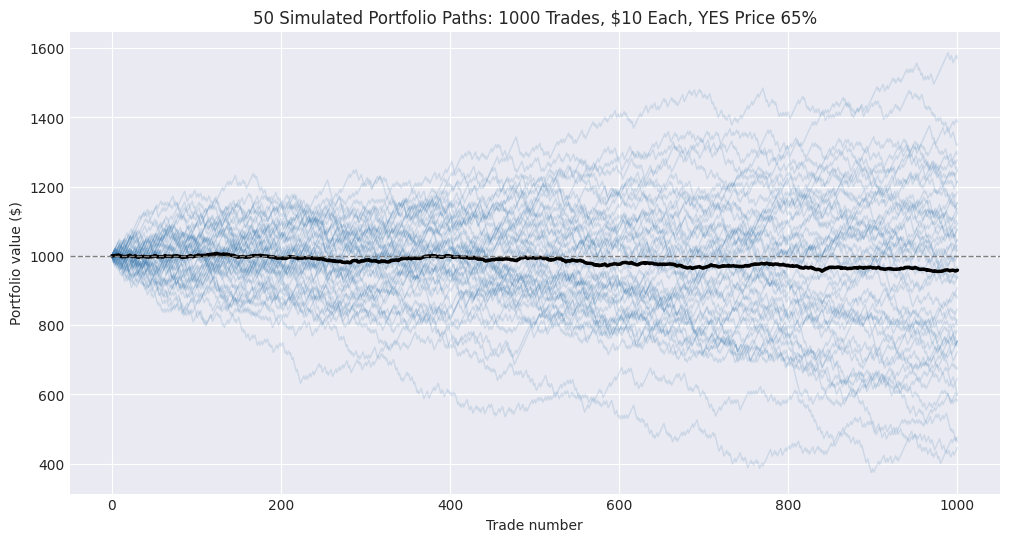

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

paths.plot(ax=ax, color="steelblue", alpha=0.18, linewidth=1, legend=False)
paths.mean(axis=1).plot(ax=ax, color="black", linewidth=2.5, label="Mean path")
ax.axhline(INITIAL_PORTFOLIO, color="gray", linestyle="--", linewidth=1, label="Starting value")

ax.set_title(
    f"{N_PATHS} Simulated Portfolio Paths: {N_TRADES} Trades, "
    f"${TRADE_STAKE:,.0f} Each, YES Price {FAIR_YES_PRICE:.0%}"
)
ax.set_xlabel("Trade number")
ax.set_ylabel("Portfolio value ($)")
# ax.legend()
plt.show()

In [19]:
ending_values = paths.iloc[-1]

summary = pd.Series(
    {
        "initial_portfolio": INITIAL_PORTFOLIO,
        "trade_stake": TRADE_STAKE,
        "n_trades": N_TRADES,
        "n_paths": N_PATHS,
        "fair_yes_price": FAIR_YES_PRICE,
        "mean_ending_value": ending_values.mean(),
        "median_ending_value": ending_values.median(),
        "min_ending_value": ending_values.min(),
        "max_ending_value": ending_values.max(),
        "ending_value_std": ending_values.std(),
        "share_profitable": (ending_values > INITIAL_PORTFOLIO).mean(),
        "share_below_start": (ending_values < INITIAL_PORTFOLIO).mean(),
        "share_ending_below_zero": (ending_values < 0).mean(),
    }
)

summary

initial_portfolio          1000.000000
trade_stake                  10.000000
n_trades                   1000.000000
n_paths                      50.000000
fair_yes_price                0.650000
mean_ending_value           958.461538
median_ending_value        1000.000000
min_ending_value            446.153846
max_ending_value           1569.230769
ending_value_std            255.214901
share_profitable              0.520000
share_below_start             0.480000
share_ending_below_zero       0.000000
dtype: float64

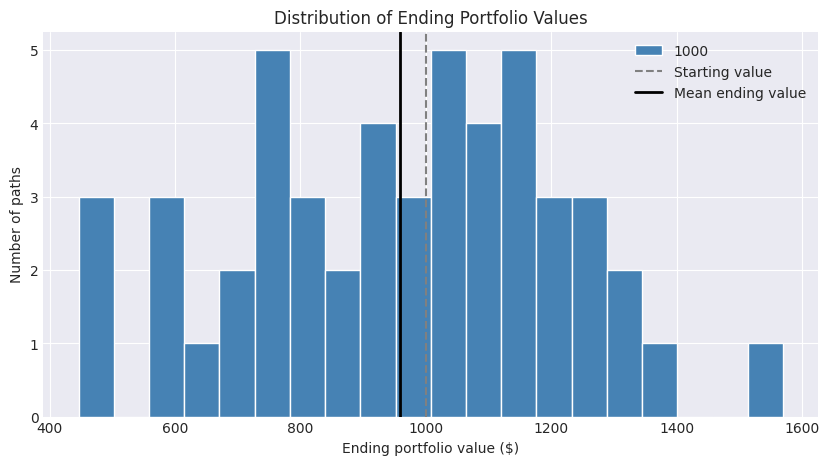

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ending_values.plot(kind="hist", bins=20, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(INITIAL_PORTFOLIO, color="gray", linestyle="--", linewidth=1.5, label="Starting value")
ax.axvline(ending_values.mean(), color="black", linewidth=2, label="Mean ending value")

ax.set_title("Distribution of Ending Portfolio Values")
ax.set_xlabel("Ending portfolio value ($)")
ax.set_ylabel("Number of paths")
ax.legend()
plt.show()

## Kelly Sizing With a 10 Point Edge

Now assume the market YES price is still `65c`, but your estimated fair value is `75c`.

For a binary YES bet:

- Market price: `q = 0.65`
- Your estimated true probability: `p = 0.75`
- Profit per `$1` staked if YES wins: `b = 1 / q - 1`
- Loss per `$1` staked if YES loses: `$1`

The full Kelly fraction is:

`f* = (b * p - (1 - p)) / b`

Equivalently, for a binary market priced at `q`:

`f* = (p - q) / (1 - q)`

With `p = 0.75` and `q = 0.65`, full Kelly stakes about `28.6%` of the current bankroll on each trade. This is aggressive, so later we may want to compare half-Kelly or capped Kelly.

In [21]:
TRUE_YES_PROBABILITY = 0.68
KELLY_FRACTION_MULTIPLIER = 1.0  # 1.0 = full Kelly, 0.5 = half Kelly


def binary_yes_kelly_fraction(market_price: float, true_probability: float) -> float:
    """Return the Kelly fraction for a YES bet in a binary market."""
    if not 0 < market_price < 1:
        raise ValueError("market_price must be between 0 and 1.")
    if not 0 < true_probability < 1:
        raise ValueError("true_probability must be between 0 and 1.")

    net_odds = 1 / market_price - 1
    raw_fraction = (net_odds * true_probability - (1 - true_probability)) / net_odds
    return max(0.0, raw_fraction)


FULL_KELLY_FRACTION = binary_yes_kelly_fraction(
    market_price=FAIR_YES_PRICE,
    true_probability=TRUE_YES_PROBABILITY,
)
ACTIVE_KELLY_FRACTION = KELLY_FRACTION_MULTIPLIER * FULL_KELLY_FRACTION

pd.Series(
    {
        "market_yes_price": FAIR_YES_PRICE,
        "estimated_true_probability": TRUE_YES_PROBABILITY,
        "edge_points": TRUE_YES_PROBABILITY - FAIR_YES_PRICE,
        "full_kelly_fraction": FULL_KELLY_FRACTION,
        "active_kelly_fraction": ACTIVE_KELLY_FRACTION,
        "initial_kelly_stake": INITIAL_PORTFOLIO * ACTIVE_KELLY_FRACTION,
    }
)

market_yes_price               0.650000
estimated_true_probability     0.680000
edge_points                    0.030000
full_kelly_fraction            0.085714
active_kelly_fraction          0.085714
initial_kelly_stake           85.714286
dtype: float64

In [22]:
def simulate_kelly_paths(
    *,
    initial_portfolio: float,
    market_price: float,
    true_probability: float,
    n_trades: int,
    n_paths: int,
    kelly_multiplier: float = 1.0,
    seed: int | None = None,
) -> pd.DataFrame:
    """Simulate repeated Kelly-sized YES bets."""
    if initial_portfolio <= 0:
        raise ValueError("initial_portfolio must be positive.")
    if kelly_multiplier < 0:
        raise ValueError("kelly_multiplier must be non-negative.")

    full_kelly = binary_yes_kelly_fraction(market_price, true_probability)
    active_fraction = kelly_multiplier * full_kelly
    win_return_multiplier = 1 + active_fraction * (1 / market_price - 1)
    loss_return_multiplier = 1 - active_fraction

    if loss_return_multiplier < 0:
        raise ValueError("Kelly fraction is above 100% of bankroll; reduce kelly_multiplier.")

    rng = np.random.default_rng(seed)
    wins = rng.random((n_trades, n_paths)) < true_probability
    return_multipliers = np.where(wins, win_return_multiplier, loss_return_multiplier)

    portfolio_values = initial_portfolio * np.vstack(
        [np.ones(n_paths), np.cumprod(return_multipliers, axis=0)]
    )

    return pd.DataFrame(
        portfolio_values,
        index=pd.RangeIndex(0, n_trades + 1, name="trade_number"),
        columns=[f"path_{i + 1}" for i in range(n_paths)],
    )


kelly_paths = simulate_kelly_paths(
    initial_portfolio=INITIAL_PORTFOLIO,
    market_price=FAIR_YES_PRICE,
    true_probability=TRUE_YES_PROBABILITY,
    n_trades=N_TRADES,
    n_paths=N_PATHS,
    kelly_multiplier=KELLY_FRACTION_MULTIPLIER,
    seed=RANDOM_SEED,
)

kelly_paths.head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_41,path_42,path_43,path_44,path_45,path_46,path_47,path_48,path_49,path_50
trade_number,,,,,,,,,,,,,,,,,,,,,
0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
1,914.285714,914.285714,914.285714,914.285714,1046.153846,1046.153846,914.285714,1046.153846,1046.153846,914.285714,...,1046.153846,1046.153846,914.285714,914.285714,1046.153846,1046.153846,1046.153846,1046.153846,1046.153846,1046.153846
2,835.918367,956.483516,956.483516,835.918367,956.483516,1094.437870,956.483516,1094.437870,1094.437870,835.918367,...,1094.437870,1094.437870,956.483516,956.483516,1094.437870,1094.437870,1094.437870,1094.437870,1094.437870,1094.437870
3,764.268222,1000.628910,874.499215,874.499215,1000.628910,1144.950387,1000.628910,1144.950387,1000.628910,874.499215,...,1144.950387,1144.950387,1000.628910,874.499215,1144.950387,1000.628910,1000.628910,1144.950387,1000.628910,1144.950387
4,698.759517,1046.811782,799.542139,799.542139,1046.811782,1197.794251,1046.811782,1046.811782,1046.811782,914.860717,...,1197.794251,1197.794251,1046.811782,914.860717,1197.794251,1046.811782,1046.811782,1046.811782,914.860717,1197.794251


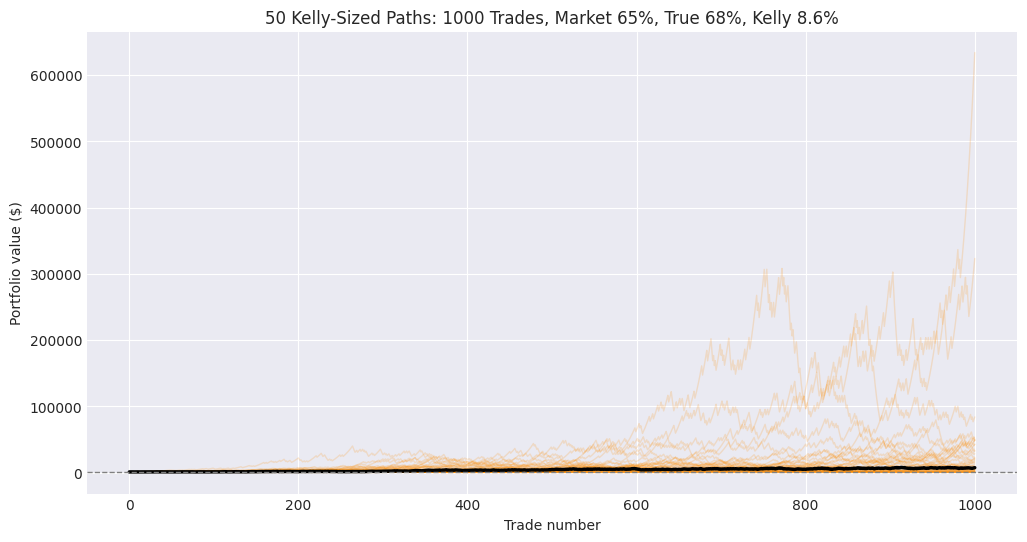

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

kelly_paths.plot(ax=ax, color="darkorange", alpha=0.18, linewidth=1, legend=False)
kelly_paths.median(axis=1).plot(ax=ax, color="black", linewidth=2.5, label="Median path")
ax.axhline(INITIAL_PORTFOLIO, color="gray", linestyle="--", linewidth=1, label="Starting value")

ax.set_title(
    f"{N_PATHS} Kelly-Sized Paths: {N_TRADES} Trades, "
    f"Market {FAIR_YES_PRICE:.0%}, True {TRUE_YES_PROBABILITY:.0%}, "
    f"Kelly {ACTIVE_KELLY_FRACTION:.1%}"
)
ax.set_xlabel("Trade number")
ax.set_ylabel("Portfolio value ($)")
plt.show()

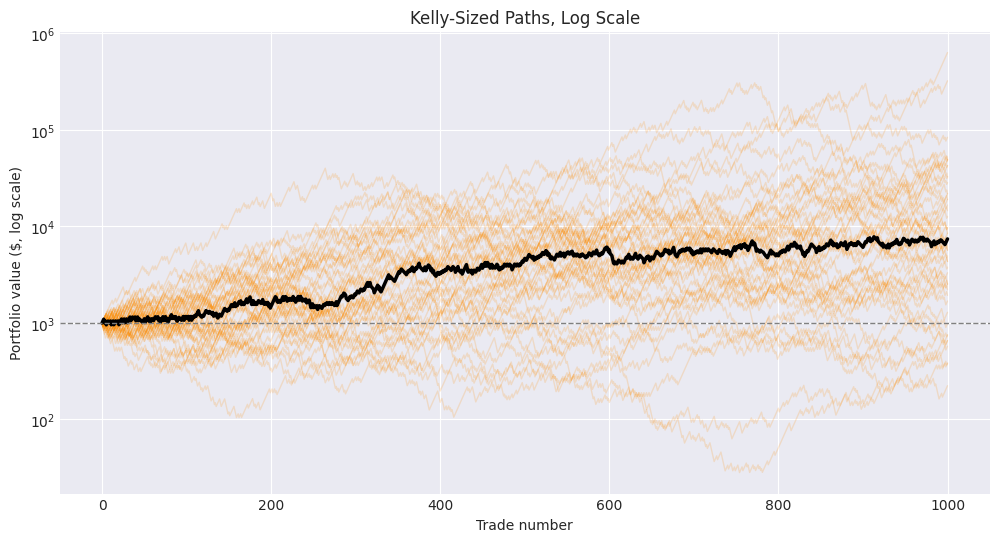

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

kelly_paths.plot(ax=ax, color="darkorange", alpha=0.18, linewidth=1, legend=False)
kelly_paths.median(axis=1).plot(ax=ax, color="black", linewidth=2.5, label="Median path")
ax.axhline(INITIAL_PORTFOLIO, color="gray", linestyle="--", linewidth=1, label="Starting value")

ax.set_yscale("log")
ax.set_title("Kelly-Sized Paths, Log Scale")
ax.set_xlabel("Trade number")
ax.set_ylabel("Portfolio value ($, log scale)")
plt.show()

In [25]:
kelly_ending_values = kelly_paths.iloc[-1]

kelly_summary = pd.Series(
    {
        "initial_portfolio": INITIAL_PORTFOLIO,
        "market_yes_price": FAIR_YES_PRICE,
        "estimated_true_probability": TRUE_YES_PROBABILITY,
        "full_kelly_fraction": FULL_KELLY_FRACTION,
        "active_kelly_fraction": ACTIVE_KELLY_FRACTION,
        "n_trades": N_TRADES,
        "n_paths": N_PATHS,
        "mean_ending_value": kelly_ending_values.mean(),
        "median_ending_value": kelly_ending_values.median(),
        "min_ending_value": kelly_ending_values.min(),
        "max_ending_value": kelly_ending_values.max(),
        "ending_value_std": kelly_ending_values.std(),
        "share_profitable": (kelly_ending_values > INITIAL_PORTFOLIO).mean(),
        "share_below_start": (kelly_ending_values < INITIAL_PORTFOLIO).mean(),
    }
)

kelly_summary

initial_portfolio               1000.000000
market_yes_price                   0.650000
estimated_true_probability         0.680000
full_kelly_fraction                0.085714
active_kelly_fraction              0.085714
n_trades                        1000.000000
n_paths                           50.000000
mean_ending_value              33210.542977
median_ending_value             7433.562434
min_ending_value                 223.791104
max_ending_value              634083.602594
ending_value_std               98746.767097
share_profitable                   0.820000
share_below_start                  0.180000
dtype: float64

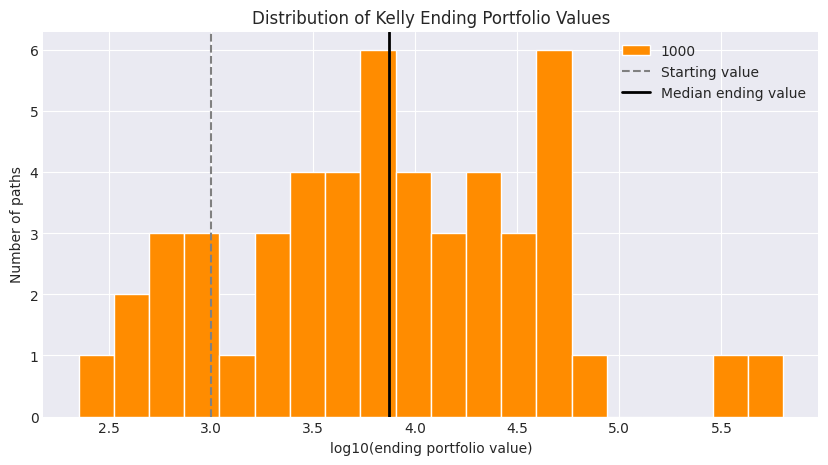

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

np.log10(kelly_ending_values).plot(kind="hist", bins=20, ax=ax, color="darkorange", edgecolor="white")
ax.axvline(np.log10(INITIAL_PORTFOLIO), color="gray", linestyle="--", linewidth=1.5, label="Starting value")
ax.axvline(np.log10(kelly_ending_values.median()), color="black", linewidth=2, label="Median ending value")

ax.set_title("Distribution of Kelly Ending Portfolio Values")
ax.set_xlabel("log10(ending portfolio value)")
ax.set_ylabel("Number of paths")
ax.legend()
plt.show()